# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, поэтому придется научиться им пользоваться

In [ ]:
from warnings import filterwarnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

Мы будем работать с датасетом по предсказанию гендера. Никакие фичи мы придумывать не будем, но если вам интересно, в датасете имеется:

- region — регион, в котором проводили опрос
- age — возраст опрошенного
- year — год опроса
- race — этническая принадлежность
- sch — количество классов образования
- empstat — статус трудоустройства
- occ — код профессии
- ind — код индустрии, в которой человек работает
- annhrs — число часов работы в год
- hrwage — почасовая оплата
- icwage — суммарная оплата в год
- occupation — должность

Целевая метрика ROC-AUC, потому что мы непритязательны и это не фокус этой домашки



In [ ]:
df = pd.read_parquet("/kaggle/input/boosting-dataset-pq")

X = df.drop("sex", axis=1)
y = df["sex"]

Пока что мы временно выкинем колонку с должностью, но мы к ней обязательно вернемся

Разделим на обучающую, валидационную и тестовую выборки (оставьте `random_state=1337` для воспроизводимости).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop("occupation", axis=1).values, y.values, test_size=0.2, random_state=1337
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_test, y_test, test_size=0.5, random_state=1337
)

X_train.shape, X_valid.shape, X_test.shape

((8000, 11), (1000, 11), (1000, 11))

---

## Базовый градиентный бустинг


Код в файле `boosting.py`.

### Инструкции для функций:

#### `__init__`

Существующие параметры:
- `base_model_class` — класс базовой модели нашего бустинга
- `base_model_params` — словарь с гиперпараметрами для базовой модели
- `n_estimators` — какое количество базовых моделей нужно обучить
- `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$
- `random_state`— в роли рандом стейта
- `verbose` — можно включить и увидеть, сколько еще ждать конца обучения

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

1. Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`).
2. После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах).
3. После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

#### `partial_fit`

В `partial_fit` передаются данные `X: np.ndarray, y: np.ndarray` для одного шага бустинга: обучаем следующую базовую модель на антиградиенте и обновляем ансамбль.

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

In [ ]:
# %load_ext autoreload

In [ ]:
import sys
# sys.path.append("/kaggle/input/boosting3")


In [ ]:
# %autoreload 2

from boosting import Boosting

добавил сюда boosting.py, чтоб не мучаться

In [ ]:
from __future__ import annotations

from collections import defaultdict
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score
from typing import Optional, Iterable
from tqdm.auto import tqdm
from sklearn.base import ClassifierMixin
from sklearn.tree import DecisionTreeClassifier


class Boosting(ClassifierMixin):
    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: Optional[dict] = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = False,
            early_stopping_rounds: int | None = 0,
            cat_features: list[int] | None = None,
            cat_smoothing: float = 20.0,
            cat_add_count: bool = True,
            cat_count_log: bool = True,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            ordered_counters: bool = False,
            quantization_type: str | None = None,
            nbins: int = 255,
            goss: bool = False,
            goss_k: float = 0.2,
    ):
        super().__init__()
        self.base_model_class = base_model_class
        self.base_model_params = base_model_params or {}
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.verbose = verbose

        self.models, self.gammas, self.model_features = [], [], []
        self.history = defaultdict(list)

        self.sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.mean(np.log(self.sigmoid(y * z) + 1e-15))
        self.loss_derivative = lambda y, z: y / (1.0 + np.exp(y * z))

        self.early_stopping_rounds = early_stopping_rounds
        self.cat_features = list(cat_features) if cat_features else []
        self.cat_smoothing = float(cat_smoothing)
        self.cat_add_count = bool(cat_add_count)
        self.cat_count_log = bool(cat_count_log)

        self._cat_stats, self._cat_prior = {}, None
        self.subsample, self.bagging_temperature = float(subsample), float(bagging_temperature)
        self.bootstrap_type = bootstrap_type
        self._rng = np.random.default_rng(self.random_state)
        self.rsm, self.ordered_counters = float(rsm), ordered_counters
        self.quantization_type, self.nbins = quantization_type, int(nbins)
        self.n_features_ = None
        self.goss = goss
        self.goss_k = goss_k

    def _fit_counters_ordered(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Реализация Ordered Target Statistics (Bonus 3.0).
        Значение для i-го объекта считается только по объектам 0...i-1.
        """
        y_binary = (y == 1).astype(float)
        self._cat_prior = np.mean(y_binary)
        n, p = X.shape

        self._fit_counters(X, y)

        results = []
        for j in range(p):
            if j not in self.cat_features:
                results.append(X[:, j].astype(float))
                continue

            col_values = X[:, j]
            res_ctr = np.zeros(n)
            res_cnt = np.zeros(n)

            # Словари для хранения накопленных сумм и количеств (running totals)
            running_stats = defaultdict(lambda: [0.0, 0.0])

            for i in range(n):
                val = col_values[i]
                cur_sum, cur_count = running_stats[val]

                # считаем CTR на основе накопленных данных (до текущего i)
                res_ctr[i] = (cur_sum + self.cat_smoothing * self._cat_prior) / (cur_count + self.cat_smoothing)
                res_cnt[i] = cur_count

                # обновляем статистики для следующих объектов
                running_stats[val][0] += y_binary[i]
                running_stats[val][1] += 1

            results.append(res_ctr)
            if self.cat_add_count:
                count_feature = np.log1p(res_cnt) if self.cat_count_log else res_cnt
                results.append(count_feature)

        return np.column_stack(results).astype(float)

    def _fit_counters(self, X: np.ndarray, y: np.ndarray):
        """Обычный расчет счетчиков по всей выборке (для теста/валидации)."""
        y_f = (y == 1).astype(float)
        self._cat_prior = np.mean(y_f)
        for j in self.cat_features:
            keys, inv = np.unique(X[:, j], return_inverse=True)
            counts = np.bincount(inv)
            pos = np.bincount(inv, weights=y_f)
            self._cat_stats[j] = {
                "uniq": keys,
                "ctr": (pos + self.cat_smoothing * self._cat_prior) / (counts + self.cat_smoothing),
                "cnt": counts.astype(float)
            }

    def _transform_counters(self, X: np.ndarray) -> np.ndarray:
        """Применяет уже обученные счетчики к новым данным (X_test, X_valid)."""
        if not self.cat_features:
            return X.astype(float)

        cols = []
        for j in range(X.shape[1]):
            if j not in self.cat_features:
                cols.append(X[:, j].astype(float))
                continue

            st = self._cat_stats[j]
            # Быстрый поиск индексов категорий
            idx = np.searchsorted(st["uniq"], X[:, j])
            valid = (idx < len(st["uniq"]))
            valid[valid] &= (st["uniq"][idx[valid]] == X[:, j][valid])

            res_ctr = np.full(X.shape[0], self._cat_prior)
            res_ctr[valid] = st["ctr"][idx[valid]]
            cols.append(res_ctr)

            if self.cat_add_count:
                c = np.zeros(X.shape[0])
                c[valid] = st["cnt"][idx[valid]]
                cols.append(np.log1p(c) if self.cat_count_log else c)

        return np.column_stack(cols).astype(float)

    def _raw_predict(self, X: np.ndarray) -> np.ndarray:
        if not self.models:
            return np.zeros(X.shape[0])
        return sum(self.learning_rate * g * m.predict(X[:, f])
                   for m, g, f in zip(self.models, self.gammas, self.model_features))

    def partial_fit(self, X: np.ndarray, y: np.ndarray):
        n = X.shape[0]
        logits = self._raw_predict(X)
        targets = self.loss_derivative(y, logits)

        # RSM: выбор случайных признаков
        f_total = X.shape[1]
        feat_indices = np.where(self._rng.random(f_total) <= self.rsm)[0]
        if not feat_indices.size:
            feat_indices = np.array([self._rng.integers(0, f_total)])

        X_fit, y_fit, weights = None, None, None

        if getattr(self, "goss", False):
            # логика GOSS
            abs_grads = np.abs(targets)
            top_k = int(self.goss_k * n)

            sorted_indices = np.argsort(abs_grads)[::-1]
            group_a = sorted_indices[:top_k]
            group_b = sorted_indices[top_k:]

            # Сэмплируем из "маленьких" градиентов
            n_b_sample = int(self.subsample * len(group_b))
            sampled_b = self._rng.choice(group_b, n_b_sample, replace=False) if n_b_sample > 0 else np.array([], dtype=int)

            idx = np.concatenate([group_a, sampled_b])
            X_fit, y_fit = X[idx][:, feat_indices], targets[idx]

            # веса для компенсации смещения
            weights = np.ones(len(idx))
            if n_b_sample > 0:
                weights[top_k:] = (1 - self.goss_k) / self.subsample
        else:
            # обычный бутстрап
            X_fit, y_fit = X[:, feat_indices], targets
            if self.bootstrap_type == "Bernoulli":
                mask = self._rng.random(n) <= self.subsample
                if not mask.any(): mask[0] = True
                X_fit, y_fit = X_fit[mask], y_fit[mask]
            elif self.bootstrap_type == "Bayesian":
                weights = (-np.log(self._rng.random(n) + 1e-12)) ** self.bagging_temperature

        model = self.base_model_class(**{**self.base_model_params, "random_state": self.random_state})
        model.fit(X_fit, y_fit, sample_weight=weights)

        # подбор гаммы на всей выборке
        new_preds = model.predict(X[:, feat_indices])
        gamma = self.find_optimal_gamma(y, logits, self.learning_rate * new_preds)

        self.models.append(model)
        self.gammas.append(gamma)
        self.model_features.append(feat_indices)
        self.history["train_loss"].append(self.loss_fn(y, logits + gamma * self.learning_rate * new_preds))

    def fit(self, X_train: np.ndarray, y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False):

        if self.cat_features:
            # Используем Ordered Counters, если флаг включен
            X_train = self._fit_counters_ordered(X_train, y_train) if self.ordered_counters \
                      else (self._fit_counters(X_train, y_train) or self._transform_counters(X_train))

            if eval_set:
                X_v, y_v = eval_set
                eval_set = (self._transform_counters(X_v), y_v)

        if self.quantization_type is not None:
            self._fit_quantization(X_train, y_train)
            X_train = self._transform_quantization(X_train)
            if eval_set is not None:
                x_v, y_v = eval_set
                eval_set = (self._transform_quantization(x_v), y_v)

        if self.quantization_type is not None:
            self._fit_quantization(X_train)
            X_train = self._transform_quantization(X_train)
            if eval_set is not None:
                x_v, y_v = eval_set
                eval_set = (self._transform_quantization(x_v), y_v)

        X_val, y_val = eval_set if eval_set else (None, None)
        best_l, best_s, p = float("inf"), 0, 0

        for i in tqdm(range(self.n_estimators)) if self.verbose else range(self.n_estimators):
            self.partial_fit(X_train, y_train)
            if X_val is not None:
                cur_l = self.loss_fn(y_val, self._raw_predict(X_val))
                self.history["valid_loss"].append(cur_l)
                if cur_l < best_l:
                    best_l, best_s, p = cur_l, i, 0
                else:
                    p += 1
                if self.early_stopping_rounds and p >= self.early_stopping_rounds: break

        if use_best_model:
            self.models, self.gammas, self.model_features = self.models[:best_s+1], self.gammas[:best_s+1], self.model_features[:best_s+1]

        for k in self.history: self.history[k] = np.array(self.history[k])
        self.n_features_ = X_train.shape[1]

    def _fit_quantization(self, X: np.ndarray, y: np.ndarray = None):
        self._quantile_bins = {}

        for j in range(X.shape[1]):
            col = X[:, j].reshape(-1, 1)

            if self.quantization_type == 'uniform':
                low, high = col.min(), col.max()
                self._quantile_bins[j] = np.linspace(low, high, self.nbins + 1)[1:-1]

            elif self.quantization_type == 'quantile':
                qs = np.linspace(0, 1, self.nbins + 1)[1:-1]
                self._quantile_bins[j] = np.unique(np.quantile(col, qs))

            elif self.quantization_type == 'piecewise':
                # Обучаем дерево небольшой глубины, чтобы найти nbins порогов
                max_depth = int(np.ceil(np.log2(self.nbins)))
                dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
                dt.fit(col, y)

                # Извлекаем все пороги (thresholds), которые дерево использовало для сплитов
                thresholds = dt.tree_.threshold[dt.tree_.feature != -2]
                self._quantile_bins[j] = np.sort(np.unique(thresholds))

    def _transform_quantization(self, X: np.ndarray) -> np.ndarray:
        if not hasattr(self, "_quantile_bins") or self.quantization_type is None:
            return X

        X_q = X.copy().astype(float)
        for j, bins in self._quantile_bins.items():
            # превращает значения в индексы бинов
            X_q[:, j] = np.digitize(X[:, j], bins)
        return X_q

    def predict_proba(self, X: np.ndarray):
        if self.cat_features and X.dtype == object:
            X = self._transform_counters(X)
        p1 = self.sigmoid(self._raw_predict(X))
        return np.column_stack([1 - p1, p1])

    def find_optimal_gamma(self, y: np.ndarray, old_predictions: np.ndarray, new_predictions: np.ndarray) -> float:
        candidates = np.linspace(0, 1, 100)
        return candidates[np.argmin([self.loss_fn(y, old_predictions + g * new_predictions) for g in candidates])]

    def score(self, X: np.ndarray, y: np.ndarray):
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

### Проверка кода

In [ ]:
boosting = Boosting(
    verbose=True,
    random_state=69,
)

boosting.fit(X_train, y_train)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"
assert np.array_equal(boosting.history["train_loss"], np.sort(boosting.history["train_loss"])[::-1]), "train loss is not decreasing"

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

  0%|          | 0/20 [00:00<?, ?it/s]

Train ROC-AUC 1.0000
Valid ROC-AUC 0.7211
Test ROC-AUC 0.7511


Хорошим знаком будет ROC-AUC в районе 0.7, в зависимости от сида.

---

## Имплементация гиперпараметров

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации.

В этом пункте мы будем делать кучу самых разных гиперпараметров, каждый из них прекрасен по-своему, но полноценно их эффект получится ощутить лишь на этапе их перебора (кроме, пожалуй, `rsm`), поэтому делать третью часть до второй не рекомендуется

После добавления каждого параметра проверим, как это повлияет на качество. Важно увидеть только, что перформанс модели изменился, в худшую или в лучшую сторону. Лучше всего это видно по графикам обучения на трейне и валидации, смотрим на них

###  Борьба с переобучением

Бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации прямо во время обучения.

Добавим в модель:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `eval_metric: str | None = None` — метрика, на которую смотрим, чтобы остановить обучение, может быть ключом из `model.history`
- `plot_history(self, keys: str | Iterable[str])` — метод, который строит график изменения метрики по ключам из `model.history`

И конкретно в метод `model.fit`:
- `eval_set: Tuple[np.ndarray] | None = None` — валидационная выборка `X_valid: np.ndarray, y_valid: np.ndarray`, на которой будем проверять переобучение
- `use_best_model: bool = False` — использовать лучшую модель, или нет. Если да, то отрезаем гаммы и модели вплоть до той, на которой остановились, минус `early_stopping_rounds`, т.е самой лучшей, после которой качество только падает

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td colspan="3" align="center"><code>early_stopping_rounds</code>, <code>eval_set</code></td>
</tr>
</table>

</div>


In [ ]:
boost = Boosting(
    n_estimators=400,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=25,
    verbose=True,
)

boost.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

print("AUC train:", round(boost.score(X_train, y_train), 4))
print("AUC valid:", round(boost.score(X_valid, y_valid), 4))

  0%|          | 0/400 [00:00<?, ?it/s]

AUC train: 1.0
AUC valid: 0.72


In [ ]:
print(len(boost.models), boost.n_estimators)


43 400


остановились раньше, на 67 итерации из 400. То есть после 43 итерации перестали улучшаться и сработала ранняя остановка.

### Бустинг линейных моделей

**Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?</font>

При ансамблировании линейных моделей бустинг строит аддитивную линейную модель, то есть сумма линейных моделей снова является линейной моделью. Поэтому мы не получаем сильно более сложную модель по сравнению с одной линейной. Но это имеет смысл, потому что бустинг обучает модели последовательно по антиградиенту, каждый раз исправляя ошибки предыдущих моделей. Такой подход может быть полезен для устойчивого обучения и работы со сложной функцией потерь, но для задач с нелинейными зависимостями он хуже, чем бустинг деревьев.

Давайте убедимся. Обучим бустинг, где в качестве базовой модели будет линейная регрессия. Сохраним историю функции потерь и время обучения.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="gblinear")</code></td>
<td align="center">-</td>
<td align="center">-</td>
</tr>
</table>

</div>

Training time: 0.197 seconds


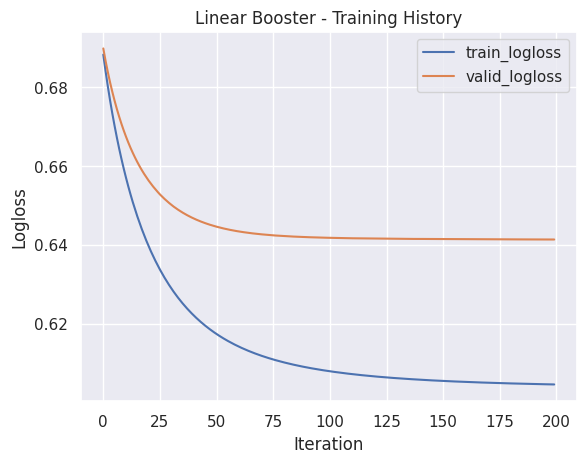

Train ROC-AUC: 0.7449
Valid ROC-AUC: 0.7176
Test  ROC-AUC: 0.7389


In [ ]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import time

y_train_xgb = np.where(y_train == 1, 1, 0)
y_valid_xgb = np.where(y_valid == 1, 1, 0)
y_test_xgb  = np.where(y_test  == 1, 1, 0)

model = XGBClassifier(
    booster="gblinear",
    n_estimators=200,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=69,
    use_label_encoder=False,
)

start_time = time.time()
model.fit(
    X_train,
    y_train_xgb,
    eval_set=[(X_train, y_train_xgb), (X_valid, y_valid_xgb)],
    verbose=False,
)
train_time = time.time() - start_time
print(f"Training time: {train_time:.3f} seconds")

history = model.evals_result()
train_loss = history["validation_0"]["logloss"]
valid_loss = history["validation_1"]["logloss"]

plt.plot(train_loss, label="train_logloss")
plt.plot(valid_loss, label="valid_logloss")
plt.xlabel("Iteration")
plt.ylabel("Logloss")
plt.title("Linear Booster - Training History")
plt.legend()
plt.show()

train_roc = roc_auc_score(y_train_xgb, model.predict_proba(X_train)[:, 1])
valid_roc = roc_auc_score(y_valid_xgb, model.predict_proba(X_valid)[:, 1])
test_roc  = roc_auc_score(y_test_xgb,  model.predict_proba(X_test)[:, 1])

print(f"Train ROC-AUC: {train_roc:.4f}")
print(f"Valid ROC-AUC: {valid_roc:.4f}")
print(f"Test  ROC-AUC: {test_roc:.4f}")


Теперь возьмем `sklearn.linear_model.SGDClassifier` и обучим на тех же данных. Также вытащим оттуда историю функции потерь

Training time: 0.326 seconds


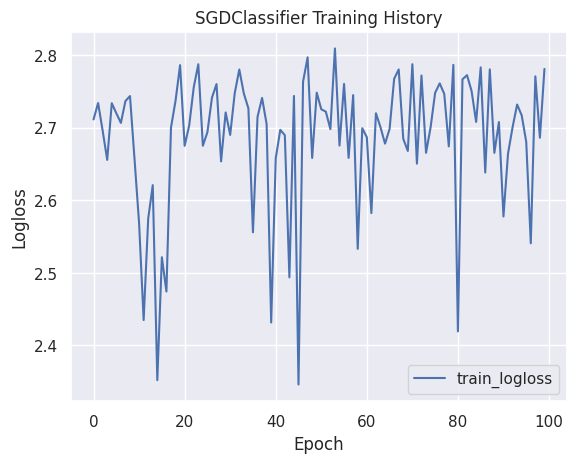

Train ROC-AUC: 0.6655
Valid ROC-AUC: 0.6294
Test  ROC-AUC: 0.6442


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
import time

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

y_train_sgd = np.where(y_train == 1, 1, 0)
y_valid_sgd = np.where(y_valid == 1, 1, 0)
y_test_sgd  = np.where(y_test  == 1, 1, 0)

sgd_model = SGDClassifier(
    loss='log_loss',
    learning_rate='optimal',
    max_iter=1,
    tol=None,
    random_state=69,
    warm_start=True,
)
train_loss_history = []
n_epochs = 100

start_time = time.time()
for epoch in range(n_epochs):
    sgd_model.fit(X_train_scaled, y_train_sgd)
    probs = sgd_model.predict_proba(X_train_scaled)[:, 1]
    eps = 1e-15
    probs = np.clip(probs, eps, 1-eps)
    loss = -(y_train_sgd*np.log(probs) + (1-y_train_sgd)*np.log(1-probs)).mean()
    train_loss_history.append(loss)
train_time = time.time() - start_time
print(f"Training time: {train_time:.3f} seconds")

plt.plot(train_loss_history, label="train_logloss")
plt.xlabel("Epoch")
plt.ylabel("Logloss")
plt.title("SGDClassifier Training History")
plt.legend()
plt.show()

train_roc = roc_auc_score(y_train_sgd, sgd_model.predict_proba(X_train_scaled)[:, 1])
valid_roc = roc_auc_score(y_valid_sgd, sgd_model.predict_proba(X_valid_scaled)[:, 1])
test_roc  = roc_auc_score(y_test_sgd,  sgd_model.predict_proba(X_test_scaled)[:, 1])

print(f"Train ROC-AUC: {train_roc:.4f}")
print(f"Valid ROC-AUC: {valid_roc:.4f}")
print(f"Test  ROC-AUC: {test_roc:.4f}")

На графике покажем изменение функции потерь для бустинга и SGD классификатора. Сравним следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

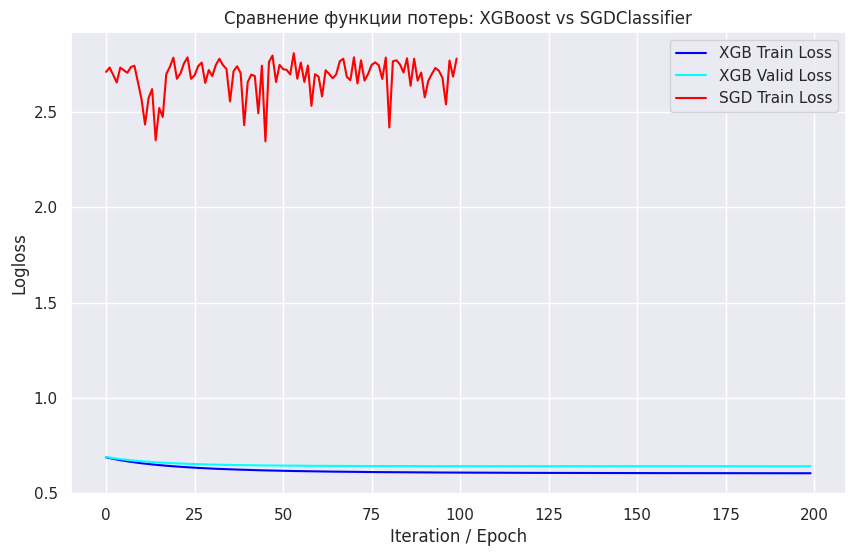

In [ ]:
plt.figure(figsize=(10,6))

# XGBoost
plt.plot(train_loss, label='XGB Train Loss', color='blue')
plt.plot(valid_loss, label='XGB Valid Loss', color='cyan')

# SGDClassifier
plt.plot(train_loss_history, label='SGD Train Loss', color='red')

plt.xlabel('Iteration / Epoch')
plt.ylabel('Logloss')
plt.title('Сравнение функции потерь: XGBoost vs SGDClassifier')
plt.legend()
plt.grid(True)
plt.show()

**Вывод**

XGBoost с линейным бустером обучается быстро и стабильно, достигает низкого значения функции потерь и показывает хорошее обобщение, Valid ROC-AUC = 0.718 и Test = 0.739.

SGDClassifier обучается медленно и нестабильно, потеря на трейне высокая и колеблется, а ROC-AUC значительно ниже (Valid = 0.629, Test = 0.644).

Ансамблирование линейных моделей через бустинг повышает качество по сравнению с одной линейной моделью, улучшает сходимость и стабильность обучения.

### Категории 2.0

Пока что для простоты картины мы игнорировали категориальные признаки. <font color='#c4bf0a'>CatBoost</font> в частности предлагает один из самых эффективных и быстрых вариантов кодировки категорий, который мы попробуем повторить

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$


Добавим в модель:
- `cat_features: Iterable | None` — категориальные признаки для кодирования
- `_cat_fit(self, X: np.array, y: np.ndarray)` — внутренний метод для построения счетчиков
- `_cat_transform(self, X: np.ndarray)` — внутренний метод для применения счетчиков

Сделаем энкодер отдельным классом с аналогичными методами `fit` и `transform`, это даже лучше. Его нужно прогнать всего раз для каждой из выборок

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center">-</td>
<td align="center"><code>cat_features</code></td>
</tr>
</table>

</div>

Закодируем категориальные переменные с помощью счётчиков (без готовых реализаций) и покажем эффект.

In [ ]:
# вернем occupation туда, где ему самое место, но это не единственная кат фича!

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=1337
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_test, y_test, test_size=0.5, random_state=1337
)

X_train.shape, X_valid.shape, X_test.shape

((8000, 12), (1000, 12), (1000, 12))

In [ ]:
# категориальные признаки
cat_cols = ["region", "occupation", "race"]
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

boost = Boosting(
    n_estimators=400,
    learning_rate=0.05,
    random_state=1337,
    early_stopping_rounds=25,
    verbose=True,

    # включаем счётчики для этих признаков
    cat_features=cat_idx,
    cat_smoothing=150.0,      # сглаживание
    cat_add_count=True,       # добавляем колонку с count
    cat_count_log=True,       # логарифмируем count
    ordered_counters=False     # full-train counters
)

boost.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

print("AUC train:", round(boost.score(X_train, y_train), 4))
print("AUC valid:", round(boost.score(X_valid, y_valid), 4))
print("AUC test :", round(boost.score(X_test, y_test), 4))

  0%|          | 0/400 [00:00<?, ?it/s]

AUC train: 1.0
AUC valid: 0.7693
AUC test : 0.7215


In [ ]:
boost = Boosting(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    verbose=True,
    cat_features=list(range(len(cat_features)))
)

boost.fit(X_train_enc, y_train, eval_set=(X_valid_enc, y_valid), use_best_model=True)

print("Train ROC-AUC:", boost.score(X_train_enc, y_train))
print("Valid ROC-AUC:", boost.score(X_valid_enc, y_valid))
print("Test  ROC-AUC:", boost.score(X_test_enc, y_test))

  0%|          | 0/50 [00:00<?, ?it/s]

Train ROC-AUC: 1.0
Valid ROC-AUC: 0.7491409965639863
Test  ROC-AUC: 0.7543811215671211


### Категории 3.0

Закодированные признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем утечку целевой переменной в признаки, но с этим можно жить, в частности это одна из главных фишек <font color='#c4bf0a'>CatBoost</font>, была.

Реализуем подсчет счетчиков так, чтобы кодировка категории была только по объектам. расположенным выше в датасете (например, если у нас выборка отсортирована по времени)

In [ ]:
boost_ordered = Boosting(
    n_estimators=400,
    learning_rate=0.05,
    random_state=1337,
    early_stopping_rounds=25,
    verbose=True,

    # включаем счётчики
    cat_features=cat_idx,
    cat_smoothing=150.0,
    cat_add_count=True,
    cat_count_log=True,
    ordered_counters=True
)

# fit с валидацией
boost_ordered.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

print("AUC train:", round(boost_ordered.score(X_train, y_train), 4))
print("AUC valid:", round(boost_ordered.score(X_valid, y_valid), 4))
print("AUC test :", round(boost_ordered.score(X_test, y_test), 4))

  0%|          | 0/400 [00:00<?, ?it/s]

AUC train: 0.7933
AUC valid: 0.6918
AUC test : 0.7068


### Бутстрап
Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

> Идея, которая за этим стоит проста - бустинги переобучаются, как черти. Бутстрап же может сделать процесс куда более робастным и быть одним из способов регуляризации, а заодно уменьшить время обучения, в случае бутстрапа Бернулли

Реализуем параметры:
- `subsample: float = 1.0` — доля объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float = 1.0` — температура для генерации весов. Соответствует бутстрапу типа `Bayesian`. Каждому объекту присваивается вес $w$, который получается из температуры $t$, после чего объект, в количестве $w$, попадает в выборку. \
$w = (-\log(X))^t$, где $X \sim {U[0, 1]}$ \
Таким образом можно сделать симуляцию повторений, обобщив на непрерывный случай. Обычный бутстрап не умеет сэмплировать дробное число объектов, но можно сделать примерно то же самое, если размножить объект $w$ раз, либо присвоить вес. Подумайте, как это корректно реализовать в бустинге
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>subsample</code>, -</td>
<td align="center"><code>subsample</code>, <code>bagging</code></td>
<td align="center"><code>subsample</code>, <code>bootstrap_type</code></td>
</tr>
</table>

</div>

**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?

**Ответ:**

Бутстрап помогает уменьшить разброс модели, так как каждая базовая модель обучается на слегка отличающейся выборке, а усреднение предсказаний стабилизирует ансамбль. Смещение же почти не меняется, потому что каждая модель по-прежнему аппроксимирует ту же функцию. В целом бутстрап делает обучение более робастным, снижает переобучение и улучшает обобщающую способность, особенно для моделей вроде деревьев и градиентного бустинга.

In [ ]:
def run_bootstrap(bootstrap_type=None, subsample=1.0, bagging_temperature=1.0):
    """
    Запускает Boosting с выбранным типом бутстрапа и параметрами.
    """
    model = Boosting(
        n_estimators=400,
        learning_rate=0.05,
        random_state=42,
        early_stopping_rounds=25,
        verbose=True,
        cat_features=cat_idx,  # категориальные фичи

        bootstrap_type=bootstrap_type,
        subsample=subsample,
        bagging_temperature=bagging_temperature,
    )

    model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

    print(f"{bootstrap_type or 'None'} | subs={subsample} | t={bagging_temperature} | "
          f"AUC valid={round(model.score(X_valid, y_valid), 4)} | "
          f"AUC test={round(model.score(X_test, y_test), 4)}")


In [ ]:
run_bootstrap("Bernoulli", subsample=0.5)
run_bootstrap("Bayesian", bagging_temperature=0.5)

  0%|          | 0/400 [00:00<?, ?it/s]

Bernoulli | subs=0.5 | t=1.0 | AUC valid=0.8483 | AUC test=0.8434


  0%|          | 0/400 [00:00<?, ?it/s]

Bayesian | subs=1.0 | t=0.5 | AUC valid=0.8362 | AUC test=0.8252


Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать параметр `rsm`

В библиотеках это реализовано так:

<div align="center">

| <font color="#2f82d4">XGBoost</font> | <font color="#41a657">LightGBM</font> | <font color='#d1cd3b'>CatBoost</font> |
| :---: | :---: | :---: |
| `colsample_bytree`| `colsample_bytree`| `rsm`|

</div>

Добавим параметр:
- `rsm: float = 1.0` — доля признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли

In [ ]:
def run_rsm(bt=None, subs=1.0, t=1.0, rsm=1.0, title=""):
    """
    Оценивает влияние подмножества признаков (RSM) на качество бустинга.
    """
    params = {
        "n_estimators": 400,
        "learning_rate": 0.05,
        "random_state": 69,
        "early_stopping_rounds": 25,
        "verbose": True,
        "cat_features": cat_idx,
        "bootstrap_type": bt,
        "subsample": subs,
        "bagging_temperature": t,
        "rsm": rsm
    }

    boost = Boosting(**params)
    boost.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

    if hasattr(boost, "model_features") and boost.model_features:
        f_counts = np.array([len(f) for f in boost.model_features])
        unique_sets = set(tuple(sorted(f)) for f in boost.model_features)

        print(f"{title}:")
        print(f"Models trained: {len(boost.models)}")
        print(f"Feature count: Mean={f_counts.mean():.1f}, Min={f_counts.min()}, Max={f_counts.max()}")

    metrics = {
        "Train": boost.score(X_train, y_train),
        "Valid": boost.score(X_valid, y_valid),
        "Test": boost.score(X_test, y_test)
    }

    for stage, value in metrics.items():
        print(f"ROC-AUC {stage}: {value:.4f}")


configs = [
    {"bt": None, "rsm": 1.0, "title": "Base: No RSM"},
    {"bt": "Bernoulli", "subs": 0.7, "rsm": 0.7, "title": "RSM (0.7) + Bernoulli (0.7)"},
    {"bt": "Bayesian", "t": 2.0, "rsm": 0.7, "title": "RSM (0.7) + Bayesian (t=2.0)"}
]

for cfg in configs:
    run_rsm(
        bt=cfg.get("bt"),
        subs=cfg.get("subs", 1.0),
        t=cfg.get("t", 1.0),
        rsm=cfg.get("rsm", 1.0),
        title=cfg["title"]
    )

Категориальные индексы: [11]
Названия колонок: ['occupation']


  0%|          | 0/400 [00:00<?, ?it/s]

Models trained: 58
Feature count: Mean=13.0, Min=13, Max=13
Unique feature combinations: 1
ROC-AUC Train: 1.0000
ROC-AUC Valid: 0.7531
ROC-AUC Test: 0.7221
----------------------------------------


  0%|          | 0/400 [00:00<?, ?it/s]

Models trained: 320
Feature count: Mean=9.0, Min=5, Max=13
Unique feature combinations: 293
ROC-AUC Train: 1.0000
ROC-AUC Valid: 0.8513
ROC-AUC Test: 0.8517
----------------------------------------


  0%|          | 0/400 [00:00<?, ?it/s]

Models trained: 359
Feature count: Mean=9.0, Min=5, Max=13
Unique feature combinations: 325
ROC-AUC Train: 1.0000
ROC-AUC Valid: 0.8501
ROC-AUC Test: 0.8518
----------------------------------------


### GOSS

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить - ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='#53c96c'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

> Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобьем градиенты на 2 группы. Объекты с большими (по модулю) градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

Сделаем параметры:

- `goss: bool = False` — GOSS бустинг или нет
- `goss_k: float = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float = 0.3` — параметры сэмплинга Бернулли для маленьких градиентов из пункта 2.3

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center"><code>bagging='goss'</code></td>
<td align="center"><code>bootstrap_type='MVS'</code></td>
</tr>
</table>

</div>


In [ ]:
cat_idx = [i for i, dtype in enumerate(X.dtypes) if dtype == object]

def run_goss_experiment(goss=False, goss_k=0.2, subs=0.3, title=""):
    boost = Boosting(
        n_estimators=400,
        learning_rate=0.05,
        random_state=42,
        early_stopping_rounds=25,
        verbose=False,
        cat_features=cat_idx,
        # Параметры GOSS
        goss=goss,
        goss_k=goss_k,
        subsample=subs,
        rsm=0.8 # добавим немного RSM для стабильности
    )

    boost.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

    print(f"{title}:")
    print(f"AUC Valid: {boost.score(X_valid, y_valid):.4f}")
    print(f"AUC Test : {boost.score(X_test, y_test):.4f}")
    print(f"Trees trained: {len(boost.models)}")
    print("-" * 30)

# cравнение
run_goss_experiment(goss=False, title="Обычный Бустинг (без GOSS)")
run_goss_experiment(goss=True, goss_k=0.1, subs=0.1, title="GOSS (k=0.1, sub=0.1)")
run_goss_experiment(goss=True, goss_k=0.2, subs=0.2, title="GOSS (k=0.2, sub=0.2)")

=== Обычный Бустинг (без GOSS) ===
AUC Valid: 0.8503
AUC Test : 0.8546
Trees trained: 263
------------------------------
=== GOSS (k=0.1, sub=0.1) ===
AUC Valid: 0.8337
AUC Test : 0.8409
Trees trained: 400
------------------------------
=== GOSS (k=0.2, sub=0.2) ===
AUC Valid: 0.8418
AUC Test : 0.8500
Trees trained: 400
------------------------------


### Бинаризация

Вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет.

Квантизованные данные весят гораздо меньше, значений в них куда как меньше, а значит, наше обучение пойдет гораздо быстрее, к тому же все снова станет устойчивее.

Добавим параметры:
- `quantization_type: str | None = None` - тип квантизации, если она есть
- `nbins: int = 255` - число бинов для квантизации. Игнорируем, если тип квантизации не указан

Либо сделать квантизатор отдельным классом, где в `fit` запоминаются пороги, а в `transform` преобразуются фичи

Рассмотрим варианта `quantization_type`:

- `'uniform'` — значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- `'quantile'` — тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>tree_method</code></td>
<td align="center"><code>max_bin</code></td>
<td align="center"><code>quantize(...)</code></td>
</tr>
</table>

</div>

Разницу между ними вы можете увидеть на картинке, где квантизуется гауссиана

<img src="https://i.postimg.cc/gJ2SJgpN/image-2025-11-29-201502496.png">

In [ ]:
def run_quantization_test(q_type, nbins, title):
    # cоздаем модель с квантизацией
    boost = Boosting(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        cat_features=cat_idx,
        quantization_type=q_type,
        nbins=nbins,
        verbose=False
    )

    boost.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)


    X_sample_q = boost._transform_quantization(boost._transform_counters(X_train[:100]))
    unique_vals = np.unique(X_sample_q[:, 0])

    print(f"{title}:")
    print(f"AUC Test: {boost.score(X_test, y_test):.4f}")
    print(f"Max bins used: {len(unique_vals)} (expected <= {nbins})")
    print(f"First 5 unique values of feature 0: {unique_vals[:5]}")
    print("-" * 30)

# Базовый уровень без квантизации
run_quantization_test(None, 255, "No Quantization")

# Равномерная квантизация (быстрая, но чувствительна к выбросам)
run_quantization_test('uniform', 32, "Uniform (32 bins)")

# Квантильная квантизация (более устойчивая, стандарт в CatBoost/LightGBM)
run_quantization_test('quantile', 32, "Quantile (32 bins)")

No Quantization:
AUC Test: 0.7372
Max bins used: 9 (expected <= 255)
First 5 unique values of feature 0: [11. 12. 21. 22. 31.]
------------------------------
Uniform (32 bins):
AUC Test: 0.5001
Max bins used: 9 (expected <= 32)
First 5 unique values of feature 0: [ 0.  1. 10. 11. 20.]
------------------------------
Quantile (32 bins):
AUC Test: 0.5332
Max bins used: 9 (expected <= 32)
First 5 unique values of feature 0: [1. 3. 4. 5. 6.]
------------------------------


<font color='#b962c4'>**Вопрос**: как квантизация поможет в обработке выбросов и нанов?</font>

<font color='#b962c4'>**Ответ**: </font>

Квантизация эффективно гасит выбросы, собирая все аномально большие или маленькие значения в крайние бины, лишая их чрезмерного влияния на разбиения дерева. Модель видит ограниченный набор категорий (а не бесконечнотсь чисел), что делает её более устойчивой к шуму. Для нанов можно выделить отдельный выделенный индекс бина, что позволит алгоритму бустинга определить для них оптимальную ветку в процессе обучения.

<font color='#b962c4'>**Вопрос**: можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?</font>

<font color='#b962c4'>**Ответ**: </font>

Да, можно заполнить константой , но выбор числа имеет критическое значение для деревьев. Если использовать значения вне диапазона признака (например, $-1$ или $-10^9$), дерево сможет легко отделить пропуски в отдельный лист первым же сплитом. Нужно использовать числа, которые не встречаются в данных, чтобы модель не путала реальные значения с индикаторами отсутствия информации.

### 2.5. Важность признаков (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и взвешенно усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor` и знанием о гаммах), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так). Разумеется, способ не единственный, если хочется, посмотрите в документации

Допишите к бустингу:
- `feature_importances_` — атрибут, который возвращает важность признаков, согласно методу выше

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>model.get_score()</code></td>
<td align="center"><code>lightgbm.importance()</code></td>
<td align="center"><code>model.get_feature_importance()</code></td>
</tr>
</table>

</div>

Покажите, какие признаки оказались самыми важными

In [ ]:
boost = Boosting(
    n_estimators=400,
    learning_rate=0.05,
    random_state=69,
    early_stopping_rounds=25,
    verbose=False,

    cat_features=cat_idx,
    cat_smoothing=150.0,
    cat_add_count=True,
    cat_count_log=True,

    quantization_type="quantile",
    nbins=128,

    ordered_counters=True,
)

boost.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
cat_set = set(cat_idx)

feature_names = []
for j, col in enumerate(X.columns):
    if j in cat_set:
        feature_names.append(f"{col}__ctr")
        if boost.cat_add_count:
            feature_names.append(f"{col}__cnt_log" if boost.cat_count_log else f"{col}__cnt")
    else:
        feature_names.append(str(col))

imp = boost.feature_importances_

top = np.argsort(imp)[::-1][:15]

print("Топ 15 фичей:")
for i in top:
    print(f"{feature_names[i]:<25} {imp[i]:.6f}")

### Optuna

Теперь давайте проанализируем, как же правильно готовить бустинги. Нас интересует: как тюнить бустинги, какие они вообще бывают и как их интерпретировать. Посмотрим на все это по порядку

Подберем на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`

Подберем диапазон параметров самостоятельно, не забывая фиксировать сид. Найдем оптимальный набор параметров и покажем, какие из них дали наибольший прирост

In [ ]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial):
    tree_params = {
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
    }

    boosting_params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bernoulli", "Bayesian", None]),
    }

    if boosting_params["bootstrap_type"] == "Bayesian":
        boosting_params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 10.0)

    model = Boosting(
        base_model_params=tree_params,
        random_state=42,
        early_stopping_rounds=25,
        cat_features=cat_idx,
        **boosting_params
    )

    model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

    preds = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Лучшие параметры:", study.best_params)
print("Лучший ROC-AUC:", study.best_value)

[I 2025-12-21 20:47:17,358] A new study created in memory with name: no-name-e0deb4e9-d455-4349-b0f3-27b36c7cd32f
[I 2025-12-21 20:47:52,589] Trial 0 finished with value: 0.8517354069416276 and parameters: {'max_depth': 8, 'min_samples_leaf': 7, 'n_estimators': 250, 'learning_rate': 0.12239995018637018, 'rsm': 0.5169484452425614, 'subsample': 0.6348114246488987, 'bootstrap_type': 'Bernoulli'}. Best is trial 0 with value: 0.8517354069416276.
[I 2025-12-21 20:48:22,581] Trial 1 finished with value: 0.8508194032776132 and parameters: {'max_depth': 12, 'min_samples_leaf': 8, 'n_estimators': 600, 'learning_rate': 0.10466994496992034, 'rsm': 0.5075799983328317, 'subsample': 0.671819784874295, 'bootstrap_type': None}. Best is trial 0 with value: 0.8517354069416276.
[I 2025-12-21 20:48:40,784] Trial 2 finished with value: 0.840187360749443 and parameters: {'max_depth': 9, 'min_samples_leaf': 14, 'n_estimators': 150, 'learning_rate': 0.03232791744462823, 'rsm': 0.8787783997993552, 'subsample': 

KeyboardInterrupt: 